# Breast Cancer Diagnosis Prediction Using Machine Learning

## Objective
The goal of this project is to build machine learning models that can predict whether a breast tumor is malignant or benign based on features extracted from digitized images of breast cell nuclei.

## Dataset
Wisconsin Diagnostic Breast Cancer (WDBC)

• Samples: 569  
• Features: 30 numerical features  
• Classes: Malignant (M), Benign (B)

## Models Used
- Logistic Regression
- KNN
- Decision Tree
- Random Forest
- Support Vector Machine

## Why this project is important

Breast cancer is one of the most serious health conditions worldwide. Early and accurate diagnosis can greatly improve treatment outcomes. This project shows how machine learning can support medical diagnosis by learning patterns from cell nucleus measurements and helping classify tumors as malignant or benign.

## Importing Required Libraries

In this step, the required Python libraries for data preprocessing, visualization, machine learning, and model evaluation are imported.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

## Loading the Dataset

In this step, the Wisconsin Diagnostic Breast Cancer dataset is loaded into the notebook using the **pandas** library.

Since the dataset file (`wdbc.data`) does not include column headers, a list of column names is manually defined based on the dataset documentation. These column names correspond to the features describing the characteristics of cell nuclei, such as radius, texture, perimeter, area, and other related measurements.

After defining the column names, the dataset is read using `pd.read_csv()` and stored in a DataFrame called **df**, which will be used for further analysis and machine learning tasks.

In [3]:
import pandas as pd

columns = [
"id","diagnosis",
"radius_mean","texture_mean","perimeter_mean","area_mean","smoothness_mean",
"compactness_mean","concavity_mean","concave_points_mean","symmetry_mean","fractal_dimension_mean",
"radius_se","texture_se","perimeter_se","area_se","smoothness_se",
"compactness_se","concavity_se","concave_points_se","symmetry_se","fractal_dimension_se",
"radius_worst","texture_worst","perimeter_worst","area_worst","smoothness_worst",
"compactness_worst","concavity_worst","concave_points_worst","symmetry_worst","fractal_dimension_worst"
]

df = pd.read_csv("dataset/wdbc.data", header=None, names=columns)


In [5]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [9]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## Dataset Overview

The dataset contains 30 numerical features describing the characteristics of cell nuclei. These features are grouped into mean values, standard error values, and worst-case values. The target variable is diagnosis, where malignant is encoded as 1 and benign as 0.

## Data Preprocessing

The diagnosis column was converted into numerical form for machine learning. The ID column was removed because it does not contribute to prediction. Then the dataset was divided into input features and target labels. After splitting into training and testing sets, feature scaling was applied using StandardScaler.

In [11]:
df["diagnosis"] = df["diagnosis"].map({"M":1,"B":0})

In [13]:
df.drop("id", axis=1, inplace=True)

## Observation
The dataset contains more benign samples than malignant samples, but the class imbalance is not extreme. This makes the dataset suitable for standard classification methods.

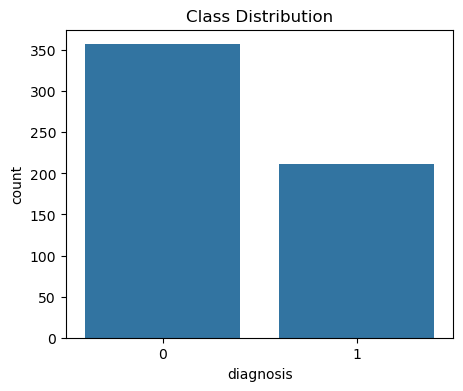

In [15]:
plt.figure(figsize=(5,4))
sns.countplot(x="diagnosis", data=df)
plt.title("Class Distribution")
plt.show()

## Feature and Target Separation

The dataset is divided into input features (X) and the target variable (y).

• X contains the 30 numerical features describing cell nuclei characteristics.
• y represents the diagnosis label, where:

1 = Malignant
0 = Benign
Separating features and target variables is necessary before training machine learning models.

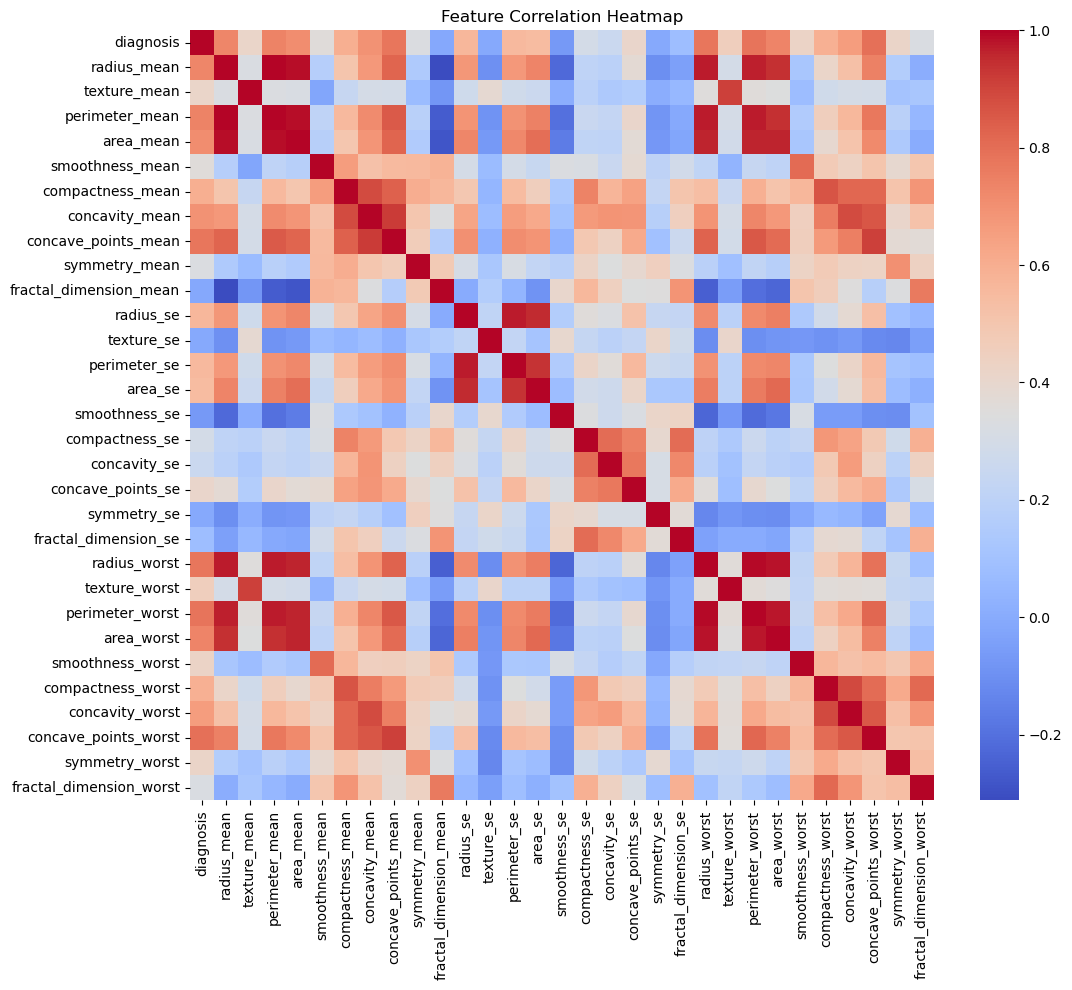

In [17]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## Observation

TThe correlation heatmap shows that several features are strongly correlated, especially among perimeter, radius, and area related variables. This suggests that some measurements carry similar information.

In [19]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

## Train-Test Split

The dataset is divided into training and testing subsets.

• 80% of the data is used for training the model.  
• 20% of the data is reserved for testing the model.

This allows us to evaluate how well the model performs on unseen data.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [23]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Feature Scaling

Feature scaling is applied using StandardScaler.

Many machine learning algorithms such as Support Vector Machine and K-Nearest Neighbors perform better when features are normalized.

StandardScaler transforms the data so that each feature has:

• mean = 0  
• standard deviation = 1

This helps improve model performance and convergence.

## Model Training

In this project, five machine learning algorithms were trained and compared:
1. Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree
4. Random Forest
5. Support Vector Machine

These models were selected to compare linear, distance-based, tree-based, ensemble, and margin-based learning approaches.

In [25]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

In [27]:
results = {}

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, predictions)
    
    results[name] = accuracy
    
    print(name, "Accuracy:", accuracy)

Logistic Regression Accuracy: 0.9736842105263158
KNN Accuracy: 0.9473684210526315
Decision Tree Accuracy: 0.9473684210526315
Random Forest Accuracy: 0.9649122807017544
SVM Accuracy: 0.9824561403508771


In [29]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

,Model,Accuracy
4,SVM,0.982456
0,Logistic Regression,0.973684
3,Random Forest,0.964912
1,KNN,0.947368
2,Decision Tree,0.947368


## Result Summary

The results show that Support Vector Machine achieved the highest accuracy among all tested models, followed by Logistic Regression and Random Forest.

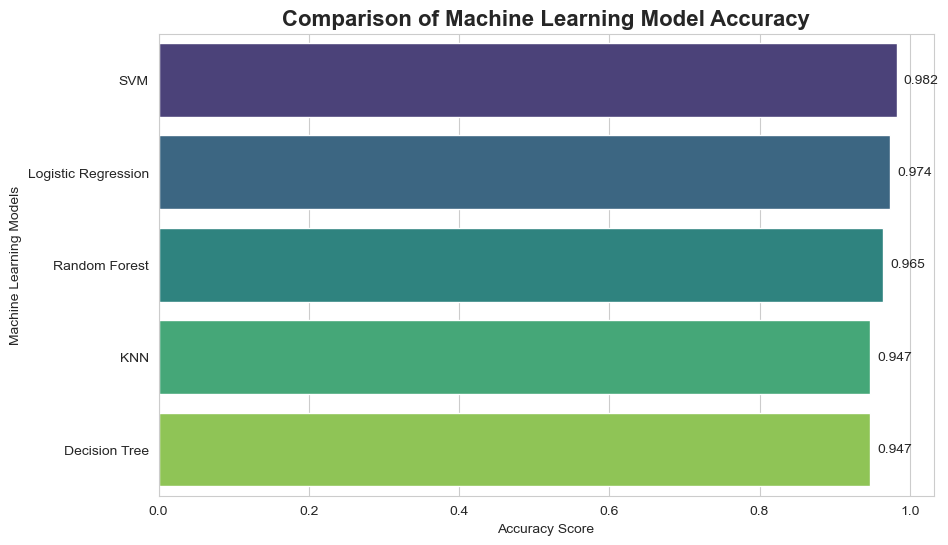

In [31]:
plt.figure(figsize=(10,6))

sns.set_style("whitegrid")

ax = sns.barplot(
    x="Accuracy",
    y="Model",
    hue="Model",
    data=results_df,
    palette="viridis",
    legend=False
)

# Add accuracy labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=5)

plt.title("Comparison of Machine Learning Model Accuracy", fontsize=16, fontweight="bold")
plt.xlabel("Accuracy Score")
plt.ylabel("Machine Learning Models")

plt.show()

## Best Model Selection

Support Vector Machine was selected as the final model because it achieved the highest test accuracy and showed excellent classification performance on this dataset.

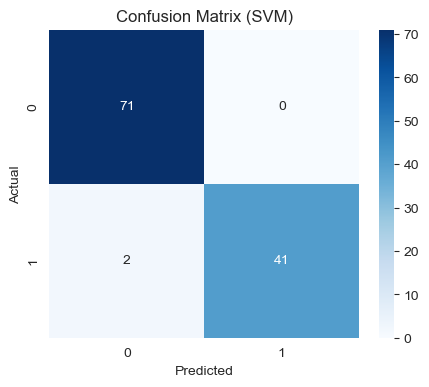

In [33]:
from sklearn.metrics import confusion_matrix, classification_report

svm_model = SVC()
svm_model.fit(X_train, y_train)
pred_svm = svm_model.predict(X_test)

cm = confusion_matrix(y_test, pred_svm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (SVM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Observation

The confusion matrix shows that the SVM model correctly classified almost all tumors, with very few misclassifications.

In [35]:
print(classification_report(y_test, pred_svm))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Observation

The classification report indicates strong precision, recall, and F1-score, confirming that the model performs well for both malignant and benign classes.

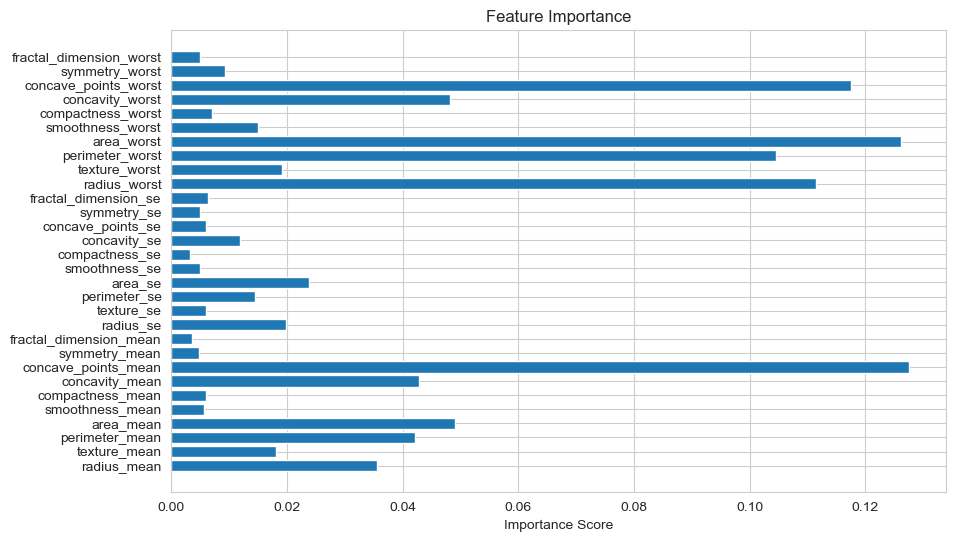

In [37]:
best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)

importances = best_model.feature_importances_

plt.figure(figsize=(10,6))
plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

## Feature Importance Analysis

Random Forest was used to estimate feature importance. The most influential features were mainly from the “worst” measurement group, such as worst radius, worst perimeter, worst area, and worst concave points.

## Cross-Validation¶
To test the reliability of the model, 10-fold cross-validation was performed. The average cross-validation accuracy confirms that the model is stable and generalizes well beyond a single train-test split.

Logistic Regression represents a linear classifier, KNN is a distance-based method, Decision Tree is a rule-based model, Random Forest is an ensemble model, and SVM is a margin-based classifier. Comparing these models provides a broader understanding of which type of learning works best for this medical dataset.

In [39]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(SVC(), X, y, cv=10)

print("Cross Validation Scores:", scores)
print("Average Cross Validation Accuracy:", scores.mean())

Cross Validation Scores: [0.89473684 0.84210526 0.89473684 0.92982456 0.92982456 0.92982456
 0.94736842 0.92982456 0.92982456 0.91071429]
Average Cross Validation Accuracy: 0.9138784461152882


## Conclusion

In this project multiple machine learning models were applied to the
Wisconsin Diagnostic Breast Cancer dataset to classify tumors as
malignant or benign.

Among all models, Support Vector Machine achieved the highest accuracy
of around 98%.

Feature importance analysis shows that worst radius, worst perimeter,
and concave points are important indicators of malignancy.

The results demonstrate that machine learning techniques can help in
early detection of breast cancer using structured medical data.

## Limitations and Future Work

Although the model achieved very high accuracy, the dataset is relatively small and contains only structured numerical features. In future work, larger datasets or image-based deep learning methods could be used to improve clinical realism. Hyperparameter tuning and dimensionality reduction techniques such as PCA could also be explored.